In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import PIL
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import tarfile
from pathlib import Path
from d2l import torch as d2l
from torchvision import transforms,datasets
from torchvision.models import resnet18

(499, 333)


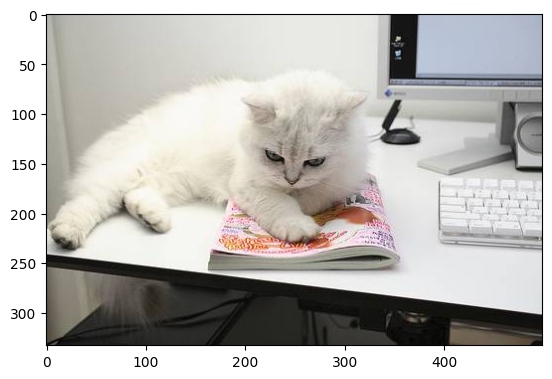

In [2]:
img_cat=Image.open("D:/Pytorch/data/cat_and_dog/train/cats/cat.666.jpg")
d2l.plt.imshow(img_cat)
print(img_cat.size)


(500, 374)


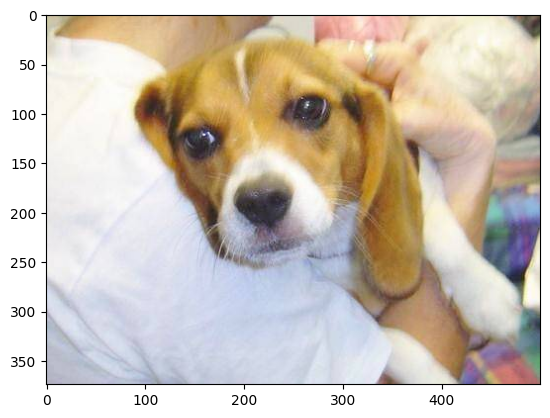

In [3]:
img_dog=Image.open("D:/Pytorch/data/cat_and_dog/train/dogs/dog.488.jpg")
d2l.plt.imshow(img_dog)
print(img_dog.size)

In [4]:
train_image_path="D:/Pytorch/data/cat_and_dog/train"
test_image_path="D:/Pytorch/data/cat_and_dog/test"
val_image_path="D:/Pytorch/data/cat_and_dog/val"

In [5]:
train_image=datasets.ImageFolder(train_image_path)
train_len=len(train_image)
print(train_len)

6000


In [6]:
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
val_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [7]:
train_dataset=datasets.ImageFolder(root=train_image_path,transform=train_transform)
test_dataset=datasets.ImageFolder(root=test_image_path,transform=test_transform)
val_dataset=datasets.ImageFolder(root=val_image_path,transform=val_transform)

In [8]:
train_load=DataLoader(
    dataset=train_dataset,
    batch_size=128,
    shuffle=True
)
test_load=DataLoader(
    dataset=test_dataset,
    batch_size=128,
    shuffle=False
)
val_load=DataLoader(
    dataset=val_dataset,
    batch_size=128,
    shuffle=False
)

In [9]:
#resnet18预训练
pre_net=resnet18(pretrained=True)
pre_net.fc

fine_net=resnet18(pretrained=True)
fine_net.fc=nn.Linear(pre_net.fc.in_features,2)
#随机权重
nn.init.xavier_uniform_(fine_net.fc.weight)

d:\Pytorch\.venv_cuda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Pytorch\.venv_cuda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Parameter containing:
tensor([[-0.0361, -0.0382, -0.0870,  ..., -0.0111, -0.0564, -0.0398],
        [-0.0314, -0.0500, -0.0351,  ..., -0.0043, -0.0737,  0.0847]],
       requires_grad=True)

In [17]:
def train_fine_tuning(net,train_iter,val_iter,learning_rate,num_epochs=10,param_groups=True):
    device=d2l.try_gpu()
    net.to(device)
    loss=nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'val acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    if param_groups:
        params_lx=[
            param for name,param in net.named_parameters() 
            if name not in ['fc.weight','fc.bias']
        ]
        trainer=torch.optim.SGD([{'params':params_lx},{'params':net.fc.parameters(),'lr':learning_rate*10}],
                                lr=learning_rate,weight_decay=0.001)
    else:
        trainer=torch.optim.SGD(net.parameters(),lr=learning_rate,weight_decay=0.001)

    for epoch in range(num_epochs):
        net.train()
        metric=d2l.Accumulator(3)
        for i,(X,y) in enumerate(train_iter):
            timer.start()
            trainer.zero_grad()
            X,y=X.to(device),y.to(device)
            y_hat=net(X)
            l=loss(y_hat,y)
            l.backward()
            trainer.step()
            metric.add(l.item()*X.shape[0],d2l.accuracy(y_hat,y),X.shape[0])
            timer.stop()

        train_l=metric[0]/metric[2]
        train_acc=metric[1]/metric[2]

        net.eval()
        val_metric = d2l.Accumulator(2)
        with torch.no_grad():
            for X, y in val_iter:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                val_metric.add(d2l.accuracy(y_hat, y), X.shape[0])
        val_acc = val_metric[0] / val_metric[1]

        animator.add(epoch + 1, (train_l, train_acc, val_acc))
        print(f'epoch {epoch+1}, loss {train_l:.3f}, train_acc {train_acc:.3f}')
        print(f"验证集准确率: {val_acc:.3f}")
        print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

epoch 10, loss 0.108, train_acc 0.961
验证集准确率: 0.968
671.3 examples/sec on cuda:0


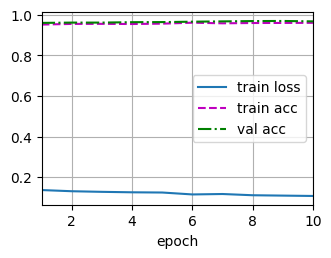

In [18]:
# 训练时用 val 验证调参
train_fine_tuning(fine_net, train_load, val_load, learning_rate=1e-4)

In [19]:
# 最终测试集评估（只跑一次，不参与训练和调参）
device = d2l.try_gpu()
fine_net.eval()
fine_net.to(device)

test_metric = d2l.Accumulator(2)
with torch.no_grad():
    for X, y in test_load:
        X, y = X.to(device), y.to(device)
        y_hat = fine_net(X)
        test_metric.add(d2l.accuracy(y_hat, y), X.shape[0])

final_test_acc = test_metric[0] / test_metric[1]
print(f'最终测试集准确率: {final_test_acc:.3f}')

最终测试集准确率: 0.968
